## Initialization

In [1]:
from torch.func import vjp
import torch
from torch.func import jacrev, functional_call
import torch.nn as nn
from torch import Tensor

import torch.nn.functional as F

import sys
import os

current_notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root_dir = os.path.abspath(os.path.join(current_notebook_dir, '../../'))

# 将这个父目录添加到sys.path的最前面
if project_root_dir not in sys.path:
    sys.path.insert(0, project_root_dir)

print(sys.path)


['/home/hqdeng7/lijuyang/generalization', '/home/hqdeng7/.conda/envs/ljy/lib/python311.zip', '/home/hqdeng7/.conda/envs/ljy/lib/python3.11', '/home/hqdeng7/.conda/envs/ljy/lib/python3.11/lib-dynload', '', '/home/hqdeng7/.conda/envs/ljy/lib/python3.11/site-packages']


In [2]:
from loss_distribution.pytorch_script.visual_utils \
	import load_cifar10_data, load_model_state_dict

from ntk_result.trials.utils import *

import torchvision
import torchvision.transforms as transforms

data_pth = '/home/hqdeng7/lijuyang/generalization/loss_distribution/pytorch_script/data/cifar10'
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
train_ds = torchvision.datasets.CIFAR10(root=data_pth, train=True, download=True, transform=transform)
test_ds = torchvision.datasets.CIFAR10(root=data_pth, train=False, download=True, transform=transform)

In [3]:
model200_path = '/home/hqdeng7/lijuyang/generalization/loss_distribution/model_training_results/cifar10_resnet20/model_200.pth'
model200 = load_model_state_dict('cifar10', 'resnet20', 10, model200_path, 'cuda')
model100_path = '/home/hqdeng7/lijuyang/generalization/loss_distribution/model_training_results/cifar10_resnet20/model_100.pth'
model100 = load_model_state_dict('cifar10', 'resnet20', 10, model100_path, 'cuda')

  从字典中提取模型状态字典...
提取成功
  从字典中提取模型状态字典...
提取成功


In [4]:
model100_losses_fn = get_batch_loss_fn(model100)
model200_losses_fn = get_batch_loss_fn(model200)
hloss_samples = {}

In [ ]:
hloss_samples[('train', 'epoch100', 'k500')] = find_topk_samples(train_ds, fn=model100_losses_fn, k=500)
hloss_samples[('train', 'epoch100', 'k2500')] = find_topk_samples(train_ds, fn=model100_losses_fn, k=2500)

hloss_samples[('test', 'epoch100', 'k100')] = find_topk_samples(test_ds, fn=model100_losses_fn, k=100)
hloss_samples[('test', 'epoch100', 'k500')] = find_topk_samples(test_ds, fn=model100_losses_fn, k=500)

hloss_samples[('train', 'epoch200', 'k500')] = find_topk_samples(train_ds, fn=model200_losses_fn, k=500)
hloss_samples[('train', 'epoch200', 'k2500')] = find_topk_samples(train_ds, fn=model200_losses_fn, k=2500)

hloss_samples[('test', 'epoch200', 'k100')] = find_topk_samples(test_ds, fn=model200_losses_fn, k=100)
hloss_samples[('test', 'epoch200', 'k500')] = find_topk_samples(test_ds, fn=model200_losses_fn, k=500)

 24%|██▍       | 48/196 [00:02<00:06, 23.25it/s]

In [ ]:
hloss_samples[('train', 'epoch100', 'k128')] = find_topk_samples(train_ds, fn=model100_losses_fn, k=128)
hloss_samples[('train', 'epoch200', 'k128')] = find_topk_samples(train_ds, fn=model200_losses_fn, k=128)
hloss_samples[('test', 'epoch100', 'k128')] = find_topk_samples(test_ds, fn=model100_losses_fn, k=128)
hloss_samples[('test', 'epoch200', 'k128')] = find_topk_samples(test_ds, fn=model200_losses_fn, k=128)

100%|██████████| 40/40 [00:01<00:00, 24.01it/s]


In [ ]:
hloss_samples_indices = {key: list(zip(*value))[1] for key, value in hloss_samples.items()}	
hloss_samples_losses = {key: list(zip(*value))[0] for key, value in hloss_samples.items()}	


## High loss samples evolution over time

### ratio

In [ ]:
from tqdm import tqdm
@torch.no_grad()
def compute_total_loss(model, dl, loss_fn = nn.CrossEntropyLoss(reduction='none'), device='cuda'):
	model = model.to(device)
	model.eval()

	total_loss = 0
	for inputs, targets in tqdm(dl):
		inputs, targets = inputs.to(device), targets.to(device)
		outputs = model(inputs)
		losses = loss_fn(outputs, targets)
		total_loss += losses.sum().item()
		
	return total_loss

In [ ]:
from torch.utils.data import DataLoader, Subset
import torch.nn as nn

def compute_loss_ratio(model, set1, set2, 
					   loss_fn = nn.CrossEntropyLoss(reduction='none'), 
					   device='cuda', batch_size=512):
	'''
	set2可以是一个dataset, 也可以是loss值
	Return: set1_loss / set2_loss
	'''
	set1_dl = DataLoader(set1, batch_size=batch_size, shuffle=False)
	set1_loss = compute_total_loss(model, set1_dl, loss_fn, device)

	if isinstance(set2, (float, int)) or (torch.is_tensor(set2)):
		set2_loss = set2
	else:
		set2_dl = DataLoader(set2, batch_size=batch_size, shuffle=False)
		set2_loss = compute_total_loss(model, set2_dl, loss_fn, device)
	
	return set1_loss / set2_loss


In [ ]:
train_dl = DataLoader(train_ds, batch_size=256, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=256, shuffle=False)

epoch100_train_loss = compute_total_loss(model100, train_dl)
epoch100_test_loss = compute_total_loss(model100, test_dl)
epoch200_train_loss = compute_total_loss(model200, train_dl)
epoch200_test_loss = compute_total_loss(model200, test_dl)

In [ ]:
print('train  model100  hloss100  k500')
print(compute_loss_ratio(model100, Subset(train_ds, hloss_samples_indices[('train', 'epoch100', 'k500')]), 
						 epoch100_train_loss))
print('train  model100->200  hloss100  k500')
print(compute_loss_ratio(model200, Subset(train_ds, hloss_samples_indices[('train', 'epoch100', 'k500')]), 
						 epoch200_train_loss))

print('train  model100  hloss100  k2500')
print(compute_loss_ratio(model100, Subset(train_ds, hloss_samples_indices[('train', 'epoch100', 'k2500')]), 
						 epoch100_train_loss))
print('train  model100->200  hloss100  k2500')
print(compute_loss_ratio(model200, Subset(train_ds, hloss_samples_indices[('train', 'epoch100', 'k2500')]), 
						 epoch200_train_loss))


In [ ]:
print('test  model100  hloss100  k500')
print(compute_loss_ratio(model100, Subset(test_ds, hloss_samples_indices[('test', 'epoch100', 'k500')]), 
						 epoch100_test_loss))
print('test  model100->200  hloss100  k500')
print(compute_loss_ratio(model200, Subset(test_ds, hloss_samples_indices[('test', 'epoch100', 'k500')]), 
						 epoch200_test_loss))

### cos sim

  0%|          | 0/196 [00:00<?, ?it/s]

100%|██████████| 196/196 [00:20<00:00,  9.38it/s]


loss: 9.2012    true label: cat    pred label: frog
loss: 3.9473    true: cat    pred: frog
loss: 3.0428    true: cat    pred: frog
loss: 2.5535    true: cat    pred: frog
loss: 4.2119    true: cat    pred: frog
loss: 1.6301    true: cat    pred: frog
loss: 3.1464    true: dog    pred: frog
loss: 4.2836    true: cat    pred: frog
loss: 3.0820    true: cat    pred: frog
loss: 2.6769    true: dog    pred: frog
loss: 6.0238    true: cat    pred: frog
loss: 1.6826    true: cat    pred: frog
loss: 1.5660    true: cat    pred: frog
loss: 1.8607    true: cat    pred: frog
loss: 2.5920    true: cat    pred: frog
loss: 4.1597    true: cat    pred: ship
loss: 2.4712    true: cat    pred: frog


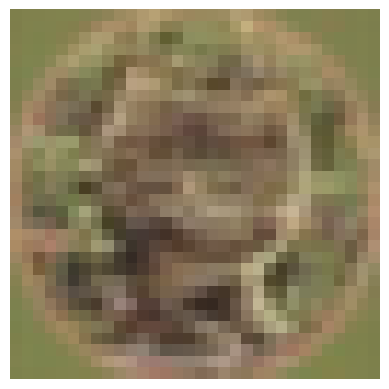

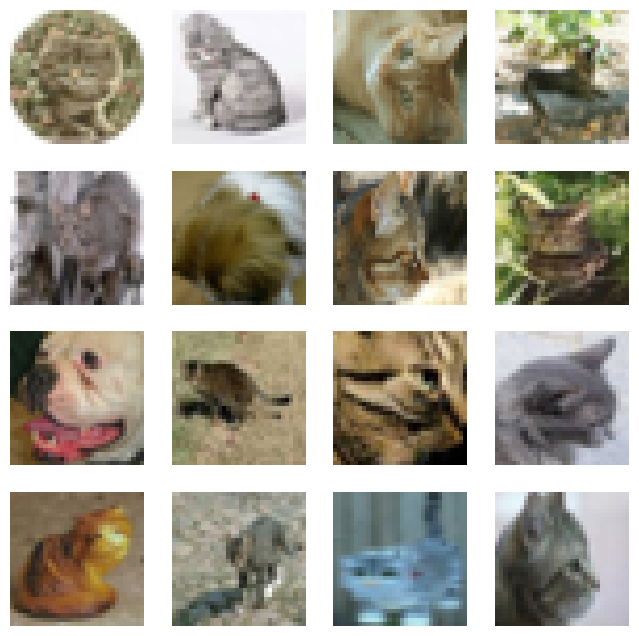

In [9]:
sample_loss_rank = 1
ref_sample_idx = hloss_samples_indices[('test', 'epoch100', 'k500')][sample_loss_rank]
ref_input, ref_label = test_ds[ref_sample_idx]
target_ds = train_ds

f = get_batch_grad_prod_fn(model100, ref_input, ref_label)
_ = plot_topk_info(model100, target_ds, f, ref_input, ref_label, batch_size=256)

In [ ]:
recover_cuda_after_oom()

In [ ]:
def get_batch_grad_cos_fn(model, 
						   ref_input, ref_label,
						   loss_fn=nn.CrossEntropyLoss(reduction='none'), 
						   device='cuda'):
	model.eval()
	loss_fn = loss_fn if loss_fn.reduction == 'none' else type(loss_fn)(reduction='none')
	model = model.to(device)

	ref_input = ref_input.to(device).unsqueeze(0)
	ref_label = torch.tensor(ref_label).to(device).unsqueeze(0)

	g_ref_dict = compute_param_grads(model, ref_input, ref_label, loss_fn, device)
	g_ref = flatten_grads_dict(g_ref_dict)[0]  # shape: [D]

	def f(batch):
		inputs, labels = batch
		inputs, labels = inputs.to(device), labels.to(device)

		grads_dict = compute_param_grads(model, inputs, labels, loss_fn, device)
		grads_flat = flatten_grads_dict(grads_dict)  # [B, D]

		# 计算与参考样本梯度的内积，shape [B]
		batch_gradcos = F.cosine_similarity(grads_flat, g_ref.unsqueeze(0), dim=1)
		return batch_gradcos.detach().cpu().tolist() 
	
	return f

In [ ]:
hloss_samples_indices[('test', 'epoch200', 'k500')][10]

In [ ]:
hloss_samples_indices[('test', 'epoch100', 'k500')].index(5924)

In [ ]:
sample_epoch200_idx = hloss_samples_indices[('test', 'epoch200', 'k500')][10]
sample_epoch100_idx = hloss_samples_indices[('test', 'epoch100', 'k500')].index(sample_epoch200_idx)
sample_loss_rank = sample_epoch100_idx
ref_sample_idx = hloss_samples_indices[('test', 'epoch100', 'k500')][sample_loss_rank]
ref_input, ref_label = test_ds[ref_sample_idx]
target_ds = train_ds

f = get_batch_grad_cos_fn(model100, ref_input, ref_label)
_ = plot_topk_info(model100, target_ds, f, ref_input, ref_label, batch_size=128)

### plot figures

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.flatten()
for i in range(16):
	idx = hloss_samples_indices[('test', 'epoch100', 'k500')][i]
	img = inverse_trans_cifar10(test_ds[idx][0])
	img_show(img, ax=axes[i])
	

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.flatten()
for i in range(16):
	idx = hloss_samples_indices[('test', 'epoch200', 'k500')][i]
	img = inverse_trans_cifar10(test_ds[idx][0])
	img_show(img, ax=axes[i])

In [ ]:
fig, axes = plt.subplots(16, 8, figsize=(16, 32))
axes = axes.flatten()

for i in range(128):
	img = train_ds[hloss_samples_indices[('train', 'epoch100', 'k500')][i]][0]
	img = inverse_trans_cifar10(img)
	img_show(img, ax=axes[i])

In [ ]:
fig, axes = plt.subplots(16, 8, figsize=(16, 32))
axes = axes.flatten()

for i in range(128):
	img = train_ds[hloss_samples_indices[('train', 'epoch200', 'k500')][i]][0]
	img = inverse_trans_cifar10(img)
	img_show(img, ax=axes[i])

In [ ]:
fig, axes = plt.subplots(16, 8, figsize=(16, 32))
axes = axes.flatten()

for i in range(128):
	img = test_ds[hloss_samples_indices[('test', 'epoch100', 'k500')][i]][0]
	img = inverse_trans_cifar10(img)
	img_show(img, ax=axes[i])

In [ ]:
fig, axes = plt.subplots(16, 8, figsize=(16, 32))
axes = axes.flatten()

for i in range(128):
	img = test_ds[hloss_samples_indices[('test', 'epoch200', 'k500')][i]][0]
	img = inverse_trans_cifar10(img)
	img_show(img, ax=axes[i])

In [ ]:
train_k500_inter = set(hloss_samples_indices[('train', 'epoch100', 'k500')]) & set(hloss_samples_indices[('train', 'epoch200', 'k500')])
test_k500_inter = set(hloss_samples_indices[('test', 'epoch100', 'k500')]) & set(hloss_samples_indices[('test', 'epoch200', 'k500')])
train_k128_inter = set(hloss_samples_indices[('train', 'epoch100', 'k128')]) & set(hloss_samples_indices[('train', 'epoch200', 'k128')])
test_k128_inter = set(hloss_samples_indices[('test', 'epoch100', 'k128')]) & set(hloss_samples_indices[('test', 'epoch200', 'k128')])

In [ ]:
len(train_k128_inter), len(test_k128_inter), len(train_k500_inter), len(test_k500_inter)

In [ ]:
fig, axes = plt.subplots(37, 8, figsize=(16, 74))
axes = axes.flatten()

for i, test_idx in enumerate(test_k500_inter):
	img = test_ds[test_idx][0]
	img = inverse_trans_cifar10(img)
	img_show(img, ax=axes[i])

In [ ]:
np.mean(list(zip(*hloss_samples[('test', 'epoch200', 'k128')]))[0])

In [ ]:
np.mean(list(zip(*hloss_samples[('test', 'epoch100', 'k128')]))[0])

In [ ]:
hloss_samples[('test', 'epoch100', 'k128')]

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame([
    {'Epoch': epoch, 'Set': split, 'Loss': loss}
    for (split, epoch, k), losses in hloss_samples_losses.items()
    if k == 'k500'
    for loss in losses
])


sns.violinplot(
    x='Set',
    y='Loss',
    hue='Epoch',
    data=df,
    split=True,
    inner='quartile',
    linewidth=1,
    order=['train', 'test'],
    hue_order=['epoch100', 'epoch200'],
    palette='Set2'
)

plt.title("top500 Loss distribution evolution")
plt.show()

In [ ]:
input, label = train_ds[0]
input_, label_ = input.unsqueeze(0), torch.tensor(label, dtype=torch.long).unsqueeze(0)
res = compute_param_gradients(model100, input_, label_)

In [ ]:
flatten_grads_dict(res).shape

In [ ]:
recover_cuda_after_oom()